In [10]:
%load_ext autoreload
%autoreload 2


## Data

### Ru Freq

In [307]:
# ru_freq_data['PoS'].unique()


In [308]:
# ru_freq_data.groupby(by='PoS').sample(n=2)


In [309]:
# ru_freq_data[ru_freq_data['PoS'] == 'pr']


In [310]:
import pandas as pd

ru_freq_data = pd.read_csv("data/freqrnc2011.csv", sep='\t')

ru_freq_data.head()


,Lemma,PoS,Freq(ipm),R,D,Doc
0,а,conj,8198.0,100,97,32332
1,а,intj,19.8,99,90,757
2,а,part,6.1,59,79,128
3,а,s,2.7,59,85,160
4,аа,intj,1.5,47,80,68


In [311]:

ru_freq_data = ru_freq_data[ru_freq_data['PoS'].isin(['s', 'adv', 'v', 'a', ])]


In [312]:
ru_freq_data = ru_freq_data[ru_freq_data['Lemma'].str.isalpha()]
ru_freq_data['Lemma'] = ru_freq_data['Lemma'].str.lower()
ru_freq_data = ru_freq_data[ru_freq_data['Lemma'].str.len() >= 3]


In [313]:
ru_freq_data


,Lemma,PoS,Freq(ipm),R,D,Doc
9,абажур,s,4.9,79,90,269
10,аббат,s,1.6,44,79,63
11,аббатство,s,0.9,33,77,40
12,аббревиатура,s,3.5,83,91,239
13,абвер,s,2.7,22,38,25
...,...,...,...,...,...,...
52133,ящерица,s,3.6,77,74,158
52134,ящерка,s,0.4,27,82,33
52135,ящик,s,75.4,100,94,1810
52136,ящичек,s,3.4,80,89,212


In [314]:
ru_freq_data['Lang'] = "RU"


In [315]:
cefr = pd.qcut(ru_freq_data["Freq(ipm)"], [.0, .1, .25, .5, .75, .9, 1], ["C2", "C1", "B2", "B1", "A2", "A1"])


In [316]:
ru_freq_data["Level"] = cefr


In [317]:
ru_freq_data[ru_freq_data['Lemma'].str.contains('-')]


,Lemma,PoS,Freq(ipm),R,D,Doc,Lang,Level


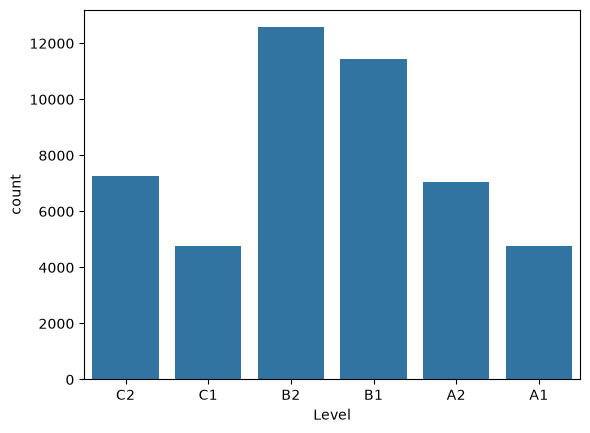

In [318]:
import seaborn as sns
import matplotlib.pyplot as plt


sns.countplot(ru_freq_data, x="Level")
plt.show()


### Eng Freq

In [266]:
import pandas as pd

eng_freq_data = pd.read_csv("data/I159729.csv")

eng_freq_data.head()


,Word,Length,Freq_HAL,Log_Freq_HAL,I_Mean_RT,I_Zscore,I_SD,Obs,I_Mean_Accuracy
0,a,1,10610626,16.18,798.92,-0.01,333.85,24.0,0.73
1,aah,3,222,5.40,816.43,0.21,186.03,21.0,0.62
2,Aaron,5,10806,9.29,736.06,-0.11,289.01,32.0,0.97
3,aback,5,387,5.96,796.27,0.11,171.61,15.0,0.45
4,abacus,6,513,6.24,964.40,0.65,489.00,15.0,0.47


In [267]:
eng_freq_data = eng_freq_data.rename(columns={"Word": "Lemma"})
eng_freq_data["Lang"] = "ENG"


In [268]:
eng_freq_data = eng_freq_data[eng_freq_data["Freq_HAL"] != 0]
eng_freq_data = eng_freq_data[eng_freq_data["Lemma"].str.isalpha()]


In [269]:
import spacy

nlp = spacy.load("en_core_web_sm")

def get_pos(word):
    tokens = nlp(word)
    if len(tokens) != 1:
        return "NPOS"
    
    return tokens[0].pos_


In [270]:
eng_freq_data['PoS'] = eng_freq_data['Lemma'].apply(get_pos)


In [271]:
eng_freq_data['PoS'].unique()


<StringArray>
[ 'PRON', 'PROPN',   'ADV',  'VERB',  'NOUN',   'ADJ',   'ADP',  'INTJ',
 'SCONJ',   'AUX', 'CCONJ',     'X',   'NUM',  'NPOS',  'PART',   'DET',
 'PUNCT']
Length: 17, dtype: str

In [272]:
eng_freq_data[eng_freq_data['PoS'] == 'ADJ']


,Lemma,Length,Freq_HAL,Log_Freq_HAL,I_Mean_RT,I_Zscore,I_SD,Obs,I_Mean_Accuracy,Lang,PoS
14,abbess,6,33,3.50,885.14,0.28,324.20,7.0,0.22,ENG,ADJ
23,abdominal,9,850,6.75,715.55,-0.13,191.24,31.0,0.94,ENG,ADJ
45,abject,6,505,6.22,692.67,0.07,162.77,9.0,0.28,ENG,ADJ
46,ablaze,6,154,5.04,740.73,0.15,175.11,22.0,0.65,ENG,ADJ
47,able,4,176528,12.08,623.30,-0.50,214.58,33.0,1.00,ENG,ADJ
...,...,...,...,...,...,...,...,...,...,...,...
40441,zealous,7,367,5.91,672.86,-0.33,165.94,28.0,0.82,ENG,ADJ
40452,zest,4,288,5.66,658.82,-0.39,115.73,34.0,0.94,ENG,ADJ
40455,Zimbabwe,8,1591,7.37,875.87,0.38,269.18,30.0,0.91,ENG,ADJ
40462,zippy,5,550,6.31,674.66,-0.17,189.70,29.0,0.88,ENG,ADJ


In [274]:
eng_freq_data[['Lemma', 'PoS']]


,Lemma,PoS
0,a,PRON
1,aah,PROPN
2,Aaron,PROPN
3,aback,ADV
4,abacus,PROPN
...,...,...
40474,zoom,VERB
40475,zooming,VERB
40476,zooms,NOUN
40477,zucchini,NOUN


In [275]:
eng_freq_data = eng_freq_data[eng_freq_data['PoS'].isin(['NOUN', 'VERB', 'ADV', 'ADJ'])]


In [276]:
cefr = pd.qcut(eng_freq_data["Freq_HAL"], [.0, .1, .25, .5, .75, .9, 1], ["C2", "C1", "B2", "B1", "A2", "A1"])


In [277]:
eng_freq_data["Level"] = cefr


In [278]:
eng_freq_data


,Lemma,Length,Freq_HAL,Log_Freq_HAL,I_Mean_RT,I_Zscore,I_SD,Obs,I_Mean_Accuracy,Lang,PoS,Level
3,aback,5,387,5.96,796.27,0.11,171.61,15.0,0.45,ENG,ADV,B2
6,abandoned,9,5160,8.55,860.77,-0.09,447.56,31.0,0.91,ENG,VERB,A2
7,abandoning,10,1005,6.91,740.55,-0.11,288.44,33.0,1.00,ENG,VERB,B1
8,abandonment,11,786,6.67,771.09,0.00,229.53,34.0,1.00,ENG,NOUN,B1
9,abase,5,30,3.40,803.27,0.03,309.52,22.0,0.69,ENG,VERB,C1
...,...,...,...,...,...,...,...,...,...,...,...,...
40473,zoology,7,707,6.56,685.28,-0.34,171.94,32.0,0.97,ENG,NOUN,B1
40474,zoom,4,4920,8.50,549.76,-0.76,97.65,33.0,1.00,ENG,VERB,A2
40475,zooming,7,523,6.26,709.69,-0.29,283.11,29.0,0.88,ENG,VERB,B1
40476,zooms,5,385,5.95,666.93,-0.48,232.11,30.0,0.94,ENG,NOUN,B2


In [279]:
eng_freq_data[eng_freq_data["Level"] == "C2"]


,Lemma,Length,Freq_HAL,Log_Freq_HAL,I_Mean_RT,I_Zscore,I_SD,Obs,I_Mean_Accuracy,Lang,PoS,Level
10,abasement,9,7,1.95,1037.06,0.92,311.84,17.0,0.53,ENG,NOUN,C2
61,abominate,9,3,1.10,888.59,0.51,268.72,27.0,0.82,ENG,VERB,C2
76,aboveground,11,19,2.94,830.65,0.19,187.02,31.0,0.94,ENG,ADV,C2
89,abruptness,10,23,3.14,817.68,0.33,234.22,28.0,0.82,ENG,ADJ,C2
97,absented,8,4,1.39,794.58,-0.07,325.30,26.0,0.84,ENG,VERB,C2
...,...,...,...,...,...,...,...,...,...,...,...,...
40308,yachters,8,2,0.69,1077.76,0.84,505.73,17.0,0.53,ENG,NOUN,C2
40312,yachtsmen,9,10,2.30,1002.11,0.95,419.65,19.0,0.59,ENG,NOUN,C2
40339,yaws,4,16,2.77,908.00,0.41,180.19,7.0,0.21,ENG,NOUN,C2
40351,yearningly,10,7,1.95,1045.72,0.78,409.85,25.0,0.76,ENG,ADV,C2


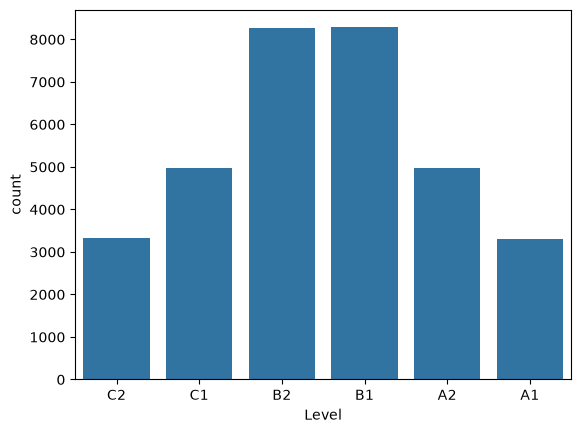

In [280]:
import seaborn as sns
import matplotlib.pyplot as plt


sns.countplot(eng_freq_data, x="Level")
plt.show()


### Ru CEFR

### Eng CEFR

## Dataset

In [322]:
data = ru_freq_data


In [323]:
from sklearn.model_selection import train_test_split

train, test = train_test_split(data, test_size=0.2, stratify=data['Level'])


In [324]:
from tokenizer import get_bpe_tokenizer, get_char_tokenizer, ENGALPHAPBET, RUALPHABET

MAX_LEN = 24

tokenizer = get_char_tokenizer(RUALPHABET, MAX_LEN)
# tokenizer = get_bpe_tokenizer(train['Lemma'])


In [325]:
PAD_IDX = tokenizer.pad_token_id
BOS_IDX = tokenizer.bos_token_id
EOS_IDX = tokenizer.eos_token_id
UNK_IDX = tokenizer.unk_token_id


In [326]:
from dataset import LLLDataset, NUM_LEVELS

dataset = LLLDataset(data[["Lemma", "Level", "Lang"]], tokenizer, max_len=MAX_LEN)


In [327]:
train_set = LLLDataset(train[["Lemma", "Level", "Lang"]], tokenizer, max_len=MAX_LEN)
test_set = LLLDataset(test[["Lemma", "Level", "Lang"]], tokenizer, max_len=MAX_LEN)


In [328]:
from torch.utils.data import Subset
import numpy as np

small_set = Subset(train_set, np.random.choice(np.arange(len(train_set)), size=32, replace=False))


In [329]:
from torch.utils.data import DataLoader

train_loader = DataLoader(train_set, batch_size=32, drop_last=True, shuffle=True)
test_loader = DataLoader(test_set, batch_size=16, drop_last=False, shuffle=False)
small_loader = DataLoader(small_set, batch_size=4, drop_last=True, shuffle=True)


## Utils

In [330]:
import torch

if torch.cuda.is_available():
    device = 'cuda'
elif torch.backends.mps.is_available():
    device = 'mps'
else:
    device = 'cpu'


print(f'using {device} device')


using mps device


In [331]:
import os.path

BASE_PATH = './checkpoints/'
get_path = lambda model_name: os.path.join(BASE_PATH, model_name)


In [332]:
import torch.nn as nn

def get_model_device(model: nn.Module):
    return next(model.parameters()).device


## Train

In [333]:
MODEL_NAME = "RuPosFreqCharLLTransformer"


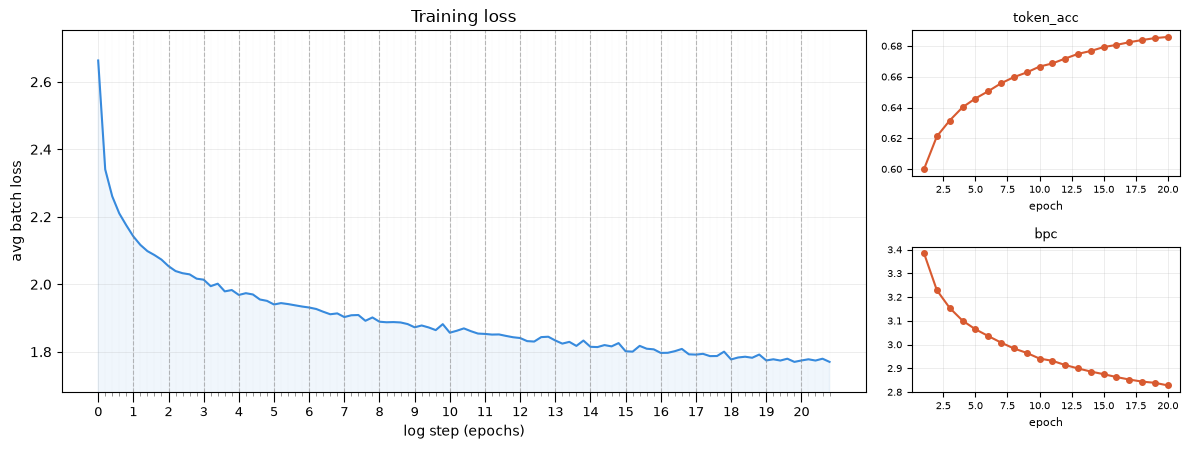

In [334]:
import torch.optim as optim
from model import LLTransformer
from utils.logger import PlotLogger, TQDMLogger
from utils.checkpointer import CheckPointer
from utils.trainer import LLTrainer
from utils.func import n_params
from utils.metrics import TokenCrossEntropyLoss, TokenAccuracy, BitsPerChar


vocab_size = len(tokenizer.get_vocab()) + len(tokenizer.get_added_vocab())
model = LLTransformer(
    vocab_size=vocab_size,
    d_model=256,
    nhead=4,
    num_layers=4,
    dim_feedforward=1024,
    num_levels=NUM_LEVELS,
    max_positions=MAX_LEN,
    pad_idx=PAD_IDX,
    dropout=0.2,
).to(device)

print(f"Trainable params: {n_params(model):,}")

chkpter = CheckPointer(model, get_path(MODEL_NAME))
logger = PlotLogger(log_every_n_step=250)
trainer = LLTrainer(model, logger, device, chkpter)

train_params = {
    'criterion': TokenCrossEntropyLoss(ignore_index=PAD_IDX),
    'opt': optim.AdamW(model.parameters(), lr=5e-5)
}

val_params = {
    'metrics': {
          'token_acc': TokenAccuracy(vocab_size, PAD_IDX),
          'bpc': BitsPerChar(tokenizer, PAD_IDX),
        #   'ppl': Perplexity(PAD_IDX),
        #   'exact_match': SequenceExactMatch(PAD_IDX)
      }
}

model = trainer.fit(train_loader, train_params, test_loader, val_params, epochs=20)


In [335]:
trainer.chkpter.chkpt_path


'./checkpoints/RuPosFreqCharLLTransformer/version_0'

In [336]:
tokenizer.save_pretrained(trainer.chkpter.chkpt_path)


('./checkpoints/RuPosFreqCharLLTransformer/version_0/tokenizer_config.json',
 './checkpoints/RuPosFreqCharLLTransformer/version_0/added_tokens.json')

In [337]:
trainer.logger.save(trainer.chkpter.chkpt_path)


## Load

In [427]:
MAX_LEN = 16


In [428]:
# tokenizer = get_char_tokenizer(RUALPHABET, MAX_LEN)
from transformers import PreTrainedTokenizerFast

tokenizer = PreTrainedTokenizerFast.from_pretrained('./checkpoints/RuPosFreqBPELLTransformer/version_0')


In [429]:
PAD_IDX = tokenizer.pad_token_id
BOS_IDX = tokenizer.bos_token_id
EOS_IDX = tokenizer.eos_token_id
UNK_IDX = tokenizer.unk_token_id


In [430]:
vocab_size


37

In [431]:
from model import LLTransformer
from dataset import NUM_LEVELS

# MAX_LEN = 8

vocab_size = len(tokenizer.get_vocab()) + len(tokenizer.get_added_vocab())
model = LLTransformer(
    vocab_size=vocab_size,
    d_model=256,
    nhead=4,
    num_layers=4,
    dim_feedforward=1024,
    num_levels=NUM_LEVELS,
    max_positions=MAX_LEN,
    pad_idx=PAD_IDX,
    dropout=0.2,
).to(device)


In [432]:
import torch

state_dict = torch.load("./checkpoints/RuPosFreqBPELLTransformer/version_0/checkpoint_20.pt")

model.load_state_dict(state_dict)


<All keys matched successfully>

## Eval

In [338]:
from utils.validity import LemmaValidator

validator = LemmaValidator()


In [339]:
from utils.generation import generate_word, generate_batch

words = generate_batch(model, 
                n=15,
                level="C1",lang="ENG", 
                tokenizer=tokenizer,
                device=device, 
                max_len=MAX_LEN, 
                do_sample=True, 
                temperature=.3
              )


In [340]:
words


['получить',
 'подрожить',
 'контральный',
 'привороть',
 'подстроить',
 'приполнить',
 'пристология',
 'пристольный',
 'выручить',
 'обладовать',
 'переполить',
 'припать',
 'приститься',
 'подрастить',
 'прикон']

In [433]:
from dataset import LEVELS

df = pd.DataFrame(columns=['legitimate','level','lemma'])

lemmas = []
levels = []
legitimate = []
lang = "RU"
n = 100
for level in LEVELS:
    _lemmas = generate_batch(model, 
                    n=n,
                    level=level,lang=lang, 
                    tokenizer=tokenizer,
                    device=device, 
                    max_len=MAX_LEN, 
                    do_sample=True, 
                    temperature=.33
              )
    _levels = [level]*n
    _legitimate = [validator.is_lemma(lemma, lang) for lemma in _lemmas]

    lemmas.extend(_lemmas)
    levels.extend(_levels)
    legitimate.extend(_legitimate)


In [434]:
df = pd.DataFrame([*zip(legitimate,levels,lemmas)], columns=['legitimate','level','lemma'])


In [435]:
df = df.drop_duplicates(subset='lemma', keep="last")


In [436]:
df.shape


(457, 3)

In [437]:
df['legitimate'].value_counts()


legitimate
True     308
False    149
Name: count, dtype: int64

In [388]:
df[~df['legitimate']]


,legitimate,level,lemma
0,False,A1,professed
3,False,A1,substron
5,False,A1,profered
7,False,A1,decomment
8,False,A1,subjection
...,...,...,...
595,False,C2,converse
596,False,C2,scrustering
597,False,C2,reproversion
598,False,C2,confortions


In [438]:
df.to_csv('../app/data/words/ru.csv', index=False)


In [ ]:
words = generate_batch(model, 
                       n=50,
                    level="C2",lang="RU", 
                    tokenizer=tokenizer,
                    device=device, 
                    max_len=MAX_LEN, 
                    do_sample=True, 
                    temperature=.3
              )


In [125]:
from utils.generation import generate_word, generate_batch

word = generate_word(model, 
              level="C1",lang="RU", 
              tokenizer=tokenizer,
              device=device, 
              max_len=MAX_LEN, 
              do_sample=True, 
              temperature=.3
              )

is_real = validator.is_lemma(word, "RU")

print(f"Generated '{word}', it is {('real' if is_real else 'fake')}")


Generated 'непризводный', it is fake


In [333]:
from torch.nn.functional import softmax
import torch
from dataset import level2idx, lang2idx


@torch.no_grad()
def generate_word(model, level, lang, tokenizer, device, max_len=32, temperature=0.8, do_sample=True):
    model.eval()

    level_idx = torch.tensor([level2idx[level]], device=device)

    generated = [BOS_IDX]

    # with torch.no_grad():
    for _ in range(max_len):
        input_ids = torch.tensor([generated], device=device)
        attention_mask = torch.ones_like(input_ids, device=device)

        logits = model(input_ids, level_idx, attention_mask)
        next_token_logits = logits[0, -1, :] / temperature


        if do_sample:
            probs = softmax(next_token_logits, dim=-1)
            next_token = torch.multinomial(probs, num_samples=1).item()
        else:
            next_token = torch.argmax(next_token_logits).item()
        if next_token == EOS_IDX:
            break

        generated.append(next_token)

    decoded = tokenizer.decode(generated[1:], skip_special_tokens=True)

    word = decoded.strip().replace(' ', '')
    return word


In [344]:
generate_word(model, "A2", "RU", tokenizer, device, max_len=MAX_LEN, do_sample=True, temperature=.8)


'инта'